# 분류 모델의 평가지표

## 오늘의 질문

**정확도(Accuracy) 하나만 보고 모델이 좋다고 판단할 수 있을까요?**

지난 시간 ML_파이프라인에서 타이타닉 생존 여부를 예측하는 모델을 만들고 정확도를 확인했습니다. 이번에는 같은 모델을 두고, 정확도 외에 어떤 지표를 함께 확인해야 하는지 살펴봅니다.

### 준비: 데이터와 모델

ML_파이프라인에서 사용한 것과 같은 방식으로 데이터를 정리하고, 같은 방식으로 학습·평가용 데이터를 나눕니다. 설정 코드를 외울 필요는 없습니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from IPython.display import display

sns.set_style("whitegrid")

font_candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic"]
available_fonts = {f.name for f in fm.fontManager.ttflist}
korean_font = next((f for f in font_candidates if f in available_fonts), None)

if korean_font:
    plt.rcParams["font.family"] = korean_font
    plt.rcParams["font.sans-serif"] = [korean_font] + plt.rcParams["font.sans-serif"]
else:
    print("한글 폰트를 찾지 못했습니다. '맑은 고딕' 또는 '나눔고딕'을 설치한 뒤 커널을 재시작하세요.")

plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("Titanic-Dataset.csv")

y = df["Survived"]
X = df.drop(columns=["Survived"])
X = X.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])
X["Sex"] = X["Sex"].map({"male": 0, "female": 1})
X["Embarked"] = X["Embarked"].map({"S": 1, "C": 2, "Q": 3})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train["Age"] = X_train["Age"].fillna(X_train["Age"].median())
X_train["Embarked"] = X_train["Embarked"].fillna(X_train["Embarked"].mode()[0])
X_test["Age"] = X_test["Age"].fillna(X_train["Age"].median())
X_test["Embarked"] = X_test["Embarked"].fillna(X_train["Embarked"].mode()[0])

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print(f"정확도: {accuracy:.3f}")

정확도: 0.804


## 1. 정확도만으로 충분할까요?

**왜 볼까요?** 정확도는 전체 중 맞춘 비율입니다. 그런데 한쪽 라벨이 훨씬 많은 데이터에서는 정확도가 높아도 실제로는 의미 있는 예측을 못하고 있을 수 있습니다.

타이타닉 데이터는 사망자(61%)가 생존자(39%)보다 많습니다. 아무 정보도 쓰지 않고 모든 승객을 '사망'으로 예측하면 정확도는 얼마가 나올까요?

In [2]:
baseline_accuracy = (y_test == 0).mean()
print(f"모두 사망으로 예측했을 때 정확도: {baseline_accuracy:.3f}")
print(f"모델 정확도: {accuracy:.3f}")

모두 사망으로 예측했을 때 정확도: 0.615
모델 정확도: 0.804


**확인:** 아무 정보도 쓰지 않은 예측도 정확도가 낮지 않게 나옵니다. 모델의 정확도가 이 기준보다 얼마나 높은지를 함께 봐야 모델이 실제로 도움이 되는지 판단할 수 있습니다.

정확도 하나로는 모델이 **어떤 종류의 예측을 틀리는지**는 알 수 없습니다. 이를 확인하는 방법이 혼동행렬입니다.

## 2. 혼동행렬(Confusion Matrix)

**왜 볼까요?** 예측과 실제 값을 표로 나누어, 어떤 조합에서 틀렸는지 확인합니다.

- 가로축: 모델이 예측한 값
- 세로축: 실제 값
- 대각선: 맞춘 경우, 대각선 밖: 틀린 경우

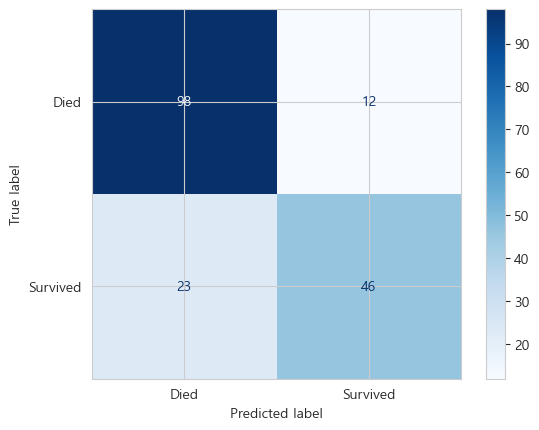

In [3]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Died", "Survived"], cmap="Blues"
)
plt.show()

**확인:** 표의 네 칸은 각각 이름이 있습니다.

| | 예측: 사망 | 예측: 생존 |
|---|---|---|
| **실제: 사망** | True Negative (TN) | False Positive (FP) |
| **실제: 생존** | False Negative (FN) | True Positive (TP) |

이 모델은 사망자는 대부분 맞추지만(TN이 많음), 생존자 중 상당수를 사망으로 잘못 예측합니다(FN이 많음). 정확도만 보면 이 차이가 드러나지 않습니다.

## 3. 정밀도(Precision)와 재현율(Recall)

**왜 볼까요?** 혼동행렬의 네 값을 하나의 숫자로 요약한 지표입니다.

- **정밀도:** 모델이 '생존'이라고 예측한 사람 중, 실제로 생존한 비율. `TP / (TP + FP)`
- **재현율:** 실제 생존자 중, 모델이 '생존'이라고 맞춘 비율. `TP / (TP + FN)`

두 지표는 같은 방향으로 움직이지 않을 수 있습니다.

In [4]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"정밀도: {precision:.3f}")
print(f"재현율: {recall:.3f}")

정밀도: 0.793
재현율: 0.667


**확인:** 재현율이 정밀도보다 낮게 나왔다면, 실제 생존자 중 놓치는 비율이 더 크다는 뜻입니다. 앞서 혼동행렬에서 본 FN(생존자를 사망으로 잘못 예측)이 많다는 관찰과 같은 내용을 숫자로 확인한 것입니다.

어떤 지표를 더 중요하게 볼지는 상황에 따라 다릅니다. 예를 들어 질병 진단에서는 실제 환자를 놓치지 않는 것(재현율)이, 스팸 메일 분류에서는 정상 메일을 스팸으로 잘못 보내지 않는 것(정밀도)이 더 중요할 수 있습니다.

## 4. F1 score

**왜 볼까요?** 정밀도와 재현율을 하나의 숫자로 함께 보고 싶을 때 사용하는 지표입니다. 두 값의 조화평균으로 계산합니다.

In [5]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
print(f"F1 score: {f1:.3f}")
print(f"정확도: {accuracy:.3f}")

F1 score: 0.724
정확도: 0.804


**확인:** F1 score가 정확도보다 낮게 나왔습니다. 모델이 두 라벨(생존/사망)을 균일하게 잘 맞춘다면 정확도와 F1 score는 비슷하게 나옵니다. 차이가 크다는 것은 한쪽 라벨에서 더 많이 틀리고 있다는 신호입니다.

## 5. 예측 확률과 임계값(Threshold)

**왜 볼까요?** 모델은 사실 0 또는 1이 아니라 '생존할 확률'을 계산하고, 그 확률이 0.5보다 크면 '생존'으로 분류합니다. 이 기준값(임계값)을 바꾸면 정밀도와 재현율이 어떻게 달라지는지 확인합니다.

In [6]:
y_proba = model.predict_proba(X_test)[:, 1]

for threshold in [0.3, 0.5, 0.7]:
    y_pred_t = (y_proba >= threshold).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    print(f"임계값 {threshold} → 정밀도 {p:.3f}, 재현율 {r:.3f}")

임계값 0.3 → 정밀도 0.655, 재현율 0.797
임계값 0.5 → 정밀도 0.793, 재현율 0.667
임계값 0.7 → 정밀도 0.895, 재현율 0.493


**확인:** 임계값을 낮추면 모델이 '생존'으로 더 쉽게 판단하게 되어 재현율은 올라가고 정밀도는 내려갑니다. 반대로 임계값을 높이면 정밀도는 올라가고 재현율은 내려갑니다. 하나를 무한정 올릴 수는 없고, 상황에 맞는 지점을 선택해야 합니다.

## 6. ROC curve

**왜 볼까요?** 임계값을 0부터 1까지 바꿔가며 True Positive Rate(재현율)와 False Positive Rate가 어떻게 변하는지 한 번에 보여주는 그래프입니다.

- 가로축: False Positive Rate — 실제 사망자 중 '생존'으로 잘못 예측한 비율
- 세로축: True Positive Rate — 실제 생존자 중 '생존'으로 맞게 예측한 비율
- 왼쪽 위 모서리에 가까울수록 좋은 모델, 대각선에 가까우면 무작위 예측과 다르지 않다는 뜻입니다.

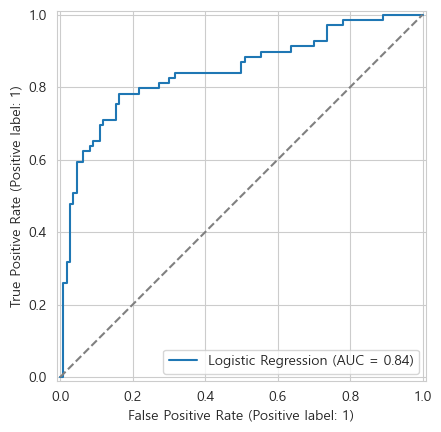

In [7]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_proba, name="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.show()

**확인:** 그래프 아래 면적(AUC)이 1에 가까울수록 좋은 모델입니다. AUC 0.5는 동전 던지기와 다르지 않다는 뜻입니다.

## 7. 한 번의 분할로 충분할까요?

지금까지의 결과는 전체 891명 중 20%인 179명을 평가용으로 나눈 결과입니다. 이 179명을 어떻게 나누느냐에 따라 결과가 조금씩 달라질 수 있습니다.

**교차검증(Cross-validation)**은 데이터를 K개로 나눠서, 매번 다른 부분을 평가용으로 사용하며 K번 반복 평가하는 방법입니다. K번의 결과를 함께 보면 평가 결과가 얼마나 안정적인지 확인할 수 있습니다.

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, StratifiedKFold

X_full = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin", "Survived"]).copy()
X_full["Sex"] = X_full["Sex"].map({"male": 0, "female": 1})
X_full["Embarked"] = X_full["Embarked"].map({"S": 1, "C": 2, "Q": 3})
y_full = df["Survived"]

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LogisticRegression(random_state=42, max_iter=1000)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X_full, y_full, cv=cv, scoring="f1")

print(f"5회 F1 score: {np.round(scores, 3)}")
print(f"평균: {scores.mean():.3f}, 표준편차: {scores.std():.3f}")

5회 F1 score: [0.714 0.729 0.694 0.715 0.763]
평균: 0.723, 표준편차: 0.023


**확인:** 5번의 평가 결과가 서로 크게 다르지 않다면, 처음에 확인한 F1 score가 우연한 분할의 결과가 아니라는 근거가 됩니다.

## 8. 오차 분석 — 어떤 승객 집단에서 더 많이 틀릴까

**왜 볼까요?** 지금까지 본 지표들은 테스트 데이터 전체를 하나의 숫자로 요약한 값입니다. 그런데 모델이 모든 승객에게 똑같이 틀리는 건 아닙니다. 특정 집단에서 유독 많이 틀린다면, 그 집단에 대한 예측은 신뢰하기 어렵다는 뜻이 됩니다.

재현율(실제 생존자 중 모델이 맞춘 비율)을 승객 등급(`Pclass`)별로 나눠서 비교해보겠습니다.

In [9]:
result = X_test.copy()
result['Survived'] = y_test
result['pred'] = y_pred
result['correct'] = (result['pred'] == result['Survived'])

survivors = result[result['Survived'] == 1]
print("recall : 실제 생존자를 생존자라고 옳게 예측한 비율")
survivors.groupby('Pclass')['correct'].agg(['mean', 'size']).rename(columns={'mean': 'recall', 'size': '생존자 수'})

recall : 실제 생존자를 생존자라고 옳게 예측한 비율


,recall,생존자 수
Pclass,,
1,0.68,25
2,0.85,20
3,0.50,24


**확인:** 3등석 생존자의 재현율이 0.50으로 가장 낮습니다. 1등석(0.68), 2등석(0.85)에 비해, 3등석 생존자는 절반을 모델이 '사망'으로 잘못 예측하고 있습니다.

**가설과 조치:** 5절에서 임계값을 낮추면 재현율이 올라간다는 걸 확인했습니다. 그렇다면 임계값을 낮춰서 다시 예측하면, 3등석 생존자도 더 많이 잡아낼 수 있지 않을까요? 실제로 임계값을 0.3으로 낮춰서 다시 확인해보겠습니다.

In [10]:
y_pred_t03 = (y_proba >= 0.3).astype(int)

result['pred_t03'] = y_pred_t03
result['correct_t03'] = (result['pred_t03'] == result['Survived'])
survivors = result[result['Survived'] == 1]

survivors.groupby('Pclass').agg(
    n=('Survived', 'size'),
    recall_05=('correct', 'mean'),
    recall_03=('correct_t03', 'mean'),
)

,n,recall_05,recall_03
Pclass,,,
1,25,0.68,0.920000
2,20,0.85,0.900000
3,24,0.50,0.583333


**확인:** 1등석(0.68→0.92)과 2등석(0.85→0.90)은 임계값을 낮춘 만큼 재현율이 크게 올랐습니다. 그런데 3등석은 0.50→0.58로, 다른 등급에 비해 기대만큼 오르지 않았습니다.

같은 조치를 똑같이 적용했는데 3등석만 효과가 작다는 건, 임계값 자체의 문제가 아니라 3등석 안에 다른 요인이 더 있다는 신호입니다. 한번 성별도 같이 확인해 볼까요?

In [11]:
print("0=남성, 1=여성")
survivors.groupby(['Pclass', 'Sex']).agg(
    n=('Survived', 'size'),
    recall_05=('correct', 'mean'),
    recall_03=('correct_t03', 'mean'),
)

0=남성, 1=여성


n  recall_05  recall_03
Pclass Sex                          
1      0    11   0.272727   0.818182
       1    14   1.000000   1.000000
2      0     3   0.000000   0.333333
       1    17   1.000000   1.000000
3      0    10   0.000000   0.000000
       1    14   0.857143   1.000000

**확인:** (`Sex`는 앞서 남성=0, 여성=1로 바꿔둔 값입니다.) 임계값을 낮췄을 때 성별로 나눠보면 왜 3등석만 효과가 작았는지 드러납니다.

- 여성 생존자는 임계값을 낮추자 모든 등급에서 재현율이 크게 오르거나 이미 높았습니다 (1등석 100%→100%, 2등석 100%→100%, 3등석 86%→100%).
- 남성 생존자는 등급이 낮을수록 임계값을 낮춰도 효과가 작습니다. 1등석 남성은 27%→82%로 크게 올랐지만, 2등석 남성은 0%→33%(3명 중 1명), 3등석 남성은 **0%→0%로 전혀 오르지 않았습니다**(10명 전원).

즉 3등석의 재현율이 잘 오르지 않은 건 임계값 문제가 아니라, 3등석에 남성 승객이 많고 이 모델이 (특히 3등석) 남성 승객에게는 애초에 생존 확률을 낮게 주고 있기 때문입니다. 임계값을 낮추는 조치로는 이 문제를 해결할 수 없었던 것입니다. 다만 2등석 남성 생존자처럼 표본이 3명뿐인 조합도 있어서, 이 비율 하나만으로 확정하기는 어렵습니다.

## 9. 개선 시도 — 등급과 성별을 묶은 특성 추가

**가설과 조치:** 지금까지 모델은 `Pclass`와 `Sex`를 각각 독립적인 특성으로만 사용했습니다. 혹시 "3등석이면서 남성"이라는 조합 자체를 하나의 새로운 특성으로 만들어 모델에 알려주면, 이 조합만의 패턴을 따로 학습해서 3등석 남성 생존자를 더 잘 잡아낼 수 있지 않을까요?

`Pclass`와 `Sex`를 합쳐 6개 그룹(`P1_S0`, `P1_S1`, ..., `P3_S1`)을 만들고, 이를 더미 변수로 바꿔 기존 특성에 추가한 뒤 다시 학습해보겠습니다.

In [12]:
combo_train = "P" + X_train["Pclass"].astype(str) + "_S" + X_train["Sex"].astype(str)
combo_test = "P" + X_test["Pclass"].astype(str) + "_S" + X_test["Sex"].astype(str)

dummies_train = pd.get_dummies(combo_train, prefix="grp")
dummies_test = pd.get_dummies(combo_test, prefix="grp").reindex(columns=dummies_train.columns, fill_value=0)

X_train_grp = pd.concat([X_train, dummies_train], axis=1)
X_test_grp = pd.concat([X_test, dummies_test], axis=1)

model_grp = LogisticRegression(random_state=42, max_iter=1000)
model_grp.fit(X_train_grp, y_train)
pred_grp = model_grp.predict(X_test_grp)

compare = pd.DataFrame({
    "기존 모델": [accuracy, precision, recall, f1],
    "등급×성별 특성 추가": [
        model_grp.score(X_test_grp, y_test),
        precision_score(y_test, pred_grp),
        recall_score(y_test, pred_grp),
        f1_score(y_test, pred_grp),
    ],
}, index=["정확도", "정밀도", "재현율", "F1 score"])
compare

,기존 모델,등급×성별 특성 추가
정확도,0.804469,0.810056
정밀도,0.793103,0.857143
재현율,0.666667,0.608696
F1 score,0.724409,0.711864


**확인:** 전체 지표만 보면 정확도(0.804→0.810)와 정밀도(0.793→0.857)는 조금 올랐지만, 재현율(0.667→0.609)과 F1 score(0.724→0.712)는 오히려 내려갔습니다.

우리가 원래 궁금했던 건 "3등석 남성 생존자를 더 잘 잡아내는가"였습니다. 이 부분을 직접 확인해보겠습니다.

In [13]:
result['pred_grp'] = pred_grp
result['correct_grp'] = (result['pred_grp'] == result['Survived'])
survivors = result[result['Survived'] == 1]

print("0=남성, 1=여성")
survivors.groupby(['Pclass', 'Sex']).agg(
    n=('Survived', 'size'),
    recall_기존=('correct', 'mean'),
    recall_그룹특성=('correct_grp', 'mean'),
)

0=남성, 1=여성


n  recall_기존  recall_그룹특성
Pclass Sex                            
1      0    11   0.272727     0.272727
       1    14   1.000000     1.000000
2      0     3   0.000000     0.000000
       1    17   1.000000     1.000000
3      0    10   0.000000     0.000000
       1    14   0.857143     0.571429

**확인:** 3등석 남성 생존자(10명)의 재현율은 0.0→0.0으로 **전혀 개선되지 않았습니다.** 오히려 3등석 여성 생존자의 재현율이 0.857→0.571로 나빠졌습니다.

`Pclass`와 `Sex`는 원래도 모델이 각각 사용하던 특성이었습니다. 이 둘을 묶은 새 특성을 추가한다고 해서 모델이 저절로 새로운 정보를 얻는 건 아니었고, 오히려 특성이 늘어나면서 다른 그룹(3등석 여성)의 예측이 흔들렸습니다.

즉 3등석 남성 생존자를 못 맞추는 문제는 특성을 어떻게 조합하느냐의 문제가 아니라, 이 그룹(생존자 10명) 자체가 다른 특성값(나이, 요금 등)으로도 사망자와 잘 구분되지 않는다는 뜻에 더 가깝습니다. "특성을 더 추가하면 항상 나아진다"는 가정도 항상 맞지는 않는다는 걸 보여주는 사례입니다.

## 정리

오늘 확인한 지표는 다음과 같습니다.

| 지표 | 확인하는 내용 |
|---|---|
| 정확도 | 전체 중 맞춘 비율 |
| 혼동행렬 | 어떤 조합(TP/FP/FN/TN)에서 맞고 틀렸는지 |
| 정밀도 | '생존' 예측 중 실제로 맞은 비율 |
| 재현율 | 실제 생존자 중 모델이 맞춘 비율 |
| F1 score | 정밀도와 재현율을 함께 본 값 |
| ROC/AUC | 임계값 전체에 걸친 성능 |
| 교차검증 | 평가 결과가 분할에 따라 얼마나 흔들리는지 |